# Project Name : Analysis of Digital Banking Infrastructure and Card Transaction Behaviour in India

## Objectives

The main objective of this project is to analyze the growth, usage and transaction patterns of ATM, PoS, QR-based payment systems, credit cards and debit cards across different banks in India using Python.


## Specific Objectives

### 1. Analyze banking infrastructure

Compare on-site and off-site ATMs, PoS terminals, Micro ATMs, Bharat QR and UPI QR across banks.

### 2. Analyze card penetration

Study the number of outstanding credit cards and debit cards across different bank categories and banks.

### 3. Analyze credit card usage

Compare credit card transactions through:
1. PoS
2. Online channels
3. Other channels
4. ATM cash withdrawals

### 4. Analyze debit card usage

Examine debit card transactions through PoS, online, other channels and cash withdrawals

### 5. Compare transaction volume and value

Identify whether different payment channels are predominantly used for high-volume or high-value transactions.

### 6. Study trends over time

Analyze how digital payment infrastructure and card transactions have changed from 2022 onwards.

### 7. Compare banks and bank categories

Identify banks with higher digital-payment infrastructure.

### 8. Identify important banking patterns

Determine the major channels driving card-based transactions and identify changes in customer payment behaviour.

## Step 1 : Importing Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import requests
from bs4 import BeautifulSoup

## Step 2 : Importing the Banking Dataset for Analysis

In [3]:
df = pd.read_csv("ATM-POS-Statistics.csv")

## Step 3 : Understanding the imported Dataset

In [9]:
df.head()

,id,date,bank_category,bank_name,atms_crms_onsite,atms_crms_offsite,pos,micro_atms,bharat_qr,upi_qr,...,dc_pay_trns_at_pos_vol,dc_pay_trns_at_pos_val,dc_pay_trns_online_vol,dc_pay_trns_online_val,dc_pay_trns_other_vol,dc_pay_trns_other_val,dc_cash_withdraw_atm_val,dc_cash_withdraw_atm_vol,dc_cash_withdraw_pos_val,dc_cash_withdraw_pos_vol
0,1,2022-03-01,Small Finance Banks,AU Small Finance Bank,407.0,3.0,0,321,0,487204,...,247593,602474.02,184714,573932.23,313,3426.59,890008,5.886433e+06,30,27.6
1,2,2022-03-01,Payment Banks,Airtel Payments Bank,0.0,0.0,0,0,0,3208634,...,0,0.00,213807,156600.18,0,0.00,0,0.000000e+00,0,0.0
2,3,2022-03-01,Foreign Banks,American Express,0.0,0.0,45455,0,0,0,...,0,0.00,0,0.00,0,0.00,0,0.000000e+00,0,0.0
3,4,2022-03-01,Private Sector Banks,Axis Bank,5748.0,11174.0,1010244,710,347644,36594577,...,12387481,27686318.61,6319140,18441049.67,26208,658186.04,22320612,1.379317e+08,0,0.0
4,5,2022-03-01,Private Sector Banks,Bandhan Bank,466.0,5.0,36339,0,0,0,...,592668,1405190.00,394699,918313.00,0,0.00,2658287,1.400377e+07,27811,27834.0


In [10]:
df.tail()

,id,date,bank_category,bank_name,atms_crms_onsite,atms_crms_offsite,pos,micro_atms,bharat_qr,upi_qr,...,dc_pay_trns_at_pos_vol,dc_pay_trns_at_pos_val,dc_pay_trns_online_vol,dc_pay_trns_online_val,dc_pay_trns_other_vol,dc_pay_trns_other_val,dc_cash_withdraw_atm_val,dc_cash_withdraw_atm_vol,dc_cash_withdraw_pos_val,dc_cash_withdraw_pos_vol
2666,2667,2025-09-01,Public Sector Banks,Union Bank of India,7866.0,1196.0,53428,8059,369473,291785,...,3588891,8505983.90,908024,2442384.88,2150,8722.95,40386186,1.188093e+08,11,2.2
2667,2668,2025-09-01,Small Finance Banks,Unity Small Finance Bank,189.0,0.0,0,0,0,0,...,7717,23757.79,1070,5767.80,0,0.00,38324,1.881812e+05,0,0.0
2668,2669,2025-09-01,Small Finance Banks,Utkarsh Small Finance Bank,301.0,5.0,0,778,0,41236,...,18070,62342.98,3982,27133.72,1,0.50,154064,9.180436e+05,0,0.0
2669,2670,2025-09-01,Foreign Banks,Woori Bank,0.0,0.0,0,0,0,0,...,1752,6635.04,684,1921.88,0,0.00,575,4.816600e+03,0,0.0
2670,2671,2025-09-01,Private Sector Banks,Yes Bank,1188.0,128.0,100668,78109,115378,546106442,...,382411,1225136.79,116553,777696.70,21,256.75,1663845,9.965342e+06,0,0.0


In [5]:
df.shape

(2671, 30)

In [12]:
df.columns

Index(['id', 'date', 'bank_category', 'bank_name', 'atms_crms_onsite',
       'atms_crms_offsite', 'pos', 'micro_atms', 'bharat_qr', 'upi_qr',
       'credit_cards', 'debit_cards', 'cc_pay_trns_at_pos_vol',
       'cc_pay_trns_at_pos_val', 'cc_pay_trns_online_vol',
       'cc_pay_trns_online_val', 'cc_pay_trns_other_vol',
       'cc_pay_trns_other_val', 'cc_cash_withdraw_atm_val',
       'cc_cash_withdraw_atm_vol', 'dc_pay_trns_at_pos_vol',
       'dc_pay_trns_at_pos_val', 'dc_pay_trns_online_vol',
       'dc_pay_trns_online_val', 'dc_pay_trns_other_vol',
       'dc_pay_trns_other_val', 'dc_cash_withdraw_atm_val',
       'dc_cash_withdraw_atm_vol', 'dc_cash_withdraw_pos_val',
       'dc_cash_withdraw_pos_vol'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2671 entries, 0 to 2670
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        2671 non-null   int64  
 1   date                      2671 non-null   str    
 2   bank_category             2671 non-null   str    
 3   bank_name                 2671 non-null   str    
 4   atms_crms_onsite          2664 non-null   float64
 5   atms_crms_offsite         2655 non-null   float64
 6   pos                       2671 non-null   int64  
 7   micro_atms                2671 non-null   int64  
 8   bharat_qr                 2671 non-null   int64  
 9   upi_qr                    2671 non-null   int64  
 10  credit_cards              2671 non-null   int64  
 11  debit_cards               2671 non-null   int64  
 12  cc_pay_trns_at_pos_vol    2669 non-null   float64
 13  cc_pay_trns_at_pos_val    2669 non-null   float64
 14  cc_pay_trns_online_

In [13]:
df.describe()

,id,atms_crms_onsite,atms_crms_offsite,pos,micro_atms,bharat_qr,upi_qr,credit_cards,debit_cards,cc_pay_trns_at_pos_vol,...,dc_pay_trns_at_pos_vol,dc_pay_trns_at_pos_val,dc_pay_trns_online_vol,dc_pay_trns_online_val,dc_pay_trns_other_vol,dc_pay_trns_other_val,dc_cash_withdraw_atm_val,dc_cash_withdraw_atm_vol,dc_cash_withdraw_pos_val,dc_cash_withdraw_pos_vol
count,2671.000000,2664.000000,2655.000000,2.671000e+03,2671.000000,2.671000e+03,2.671000e+03,2.671000e+03,2.671000e+03,2.669000e+03,...,2.671000e+03,2.671000e+03,2.671000e+03,2.671000e+03,2671.000000,2.671000e+03,2.671000e+03,2.671000e+03,2671.000000,2671.000000
mean,1336.000000,2028.725225,1473.012429,1.413899e+05,23205.326844,9.285328e+04,6.671178e+06,1.537410e+06,1.555674e+07,2.781815e+06,...,2.188121e+06,5.199525e+06,9.206808e+05,2.602492e+06,3539.369525,4.245622e+04,8.528873e+06,4.222635e+07,1823.195432,1822.704103
std,771.195609,4074.411961,5140.008633,4.303179e+05,73897.653634,2.952903e+05,4.352378e+07,4.222255e+06,3.523464e+07,9.020355e+06,...,6.008689e+06,1.382787e+07,2.668757e+06,6.994796e+06,30971.494770,2.455566e+05,2.338451e+07,1.185707e+08,8212.473137,8358.250105
min,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,668.500000,2.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,6.323550e+05,0.000000e+00,...,2.200050e+04,3.552932e+04,7.909000e+03,1.978267e+04,0.000000,0.000000e+00,9.423050e+04,3.583838e+05,0.000000,0.000000
50%,1336.000000,451.000000,38.000000,1.418000e+03,99.000000,0.000000e+00,4.123600e+04,1.161000e+04,3.764048e+06,2.590200e+04,...,2.753200e+05,6.292487e+05,1.090650e+05,2.751515e+05,0.000000,0.000000e+00,1.370925e+06,6.280297e+06,0.000000,0.000000
75%,2003.500000,1806.000000,647.000000,2.698000e+04,6686.000000,8.577500e+03,6.180955e+05,7.249470e+05,1.348254e+07,7.434080e+05,...,1.685629e+06,3.403230e+06,5.698790e+05,1.328164e+06,71.500000,6.832850e+02,6.302256e+06,3.045267e+07,18.000000,13.950000
max,2671.000000,28848.000000,40016.000000,3.314358e+06,520301.000000,2.372486e+06,5.461064e+08,2.528505e+07,2.795300e+08,9.348959e+07,...,6.138705e+07,1.301914e+08,3.351193e+07,5.455468e+07,616836.000000,4.278795e+06,2.065163e+08,1.006311e+09,83123.000000,131442.860000


## Step 4 : Data Cleaning

In [21]:
df.dtypes

id                            int64
date                            str
bank_category                   str
bank_name                       str
atms_crms_onsite            float64
atms_crms_offsite           float64
pos                           int64
micro_atms                    int64
bharat_qr                     int64
upi_qr                        int64
credit_cards                  int64
debit_cards                   int64
cc_pay_trns_at_pos_vol      float64
cc_pay_trns_at_pos_val      float64
cc_pay_trns_online_vol      float64
cc_pay_trns_online_val      float64
cc_pay_trns_other_vol       float64
cc_pay_trns_other_val       float64
cc_cash_withdraw_atm_val    float64
cc_cash_withdraw_atm_vol    float64
dc_pay_trns_at_pos_vol        int64
dc_pay_trns_at_pos_val      float64
dc_pay_trns_online_vol        int64
dc_pay_trns_online_val      float64
dc_pay_trns_other_vol         int64
dc_pay_trns_other_val       float64
dc_cash_withdraw_atm_val      int64
dc_cash_withdraw_atm_vol    

In [5]:
# Data type correction
# Convert date columns to datetime

df["date"] = pd.to_datetime(df["date"])
df.dtypes

id                                   int64
date                        datetime64[us]
bank_category                          str
bank_name                              str
atms_crms_onsite                   float64
atms_crms_offsite                  float64
pos                                  int64
micro_atms                           int64
bharat_qr                            int64
upi_qr                               int64
credit_cards                         int64
debit_cards                          int64
cc_pay_trns_at_pos_vol             float64
cc_pay_trns_at_pos_val             float64
cc_pay_trns_online_vol             float64
cc_pay_trns_online_val             float64
cc_pay_trns_other_vol              float64
cc_pay_trns_other_val              float64
cc_cash_withdraw_atm_val           float64
cc_cash_withdraw_atm_vol           float64
dc_pay_trns_at_pos_vol               int64
dc_pay_trns_at_pos_val             float64
dc_pay_trns_online_vol               int64
dc_pay_trns

In [6]:
df.isnull().sum()

id                           0
date                         0
bank_category                0
bank_name                    0
atms_crms_onsite             7
atms_crms_offsite           16
pos                          0
micro_atms                   0
bharat_qr                    0
upi_qr                       0
credit_cards                 0
debit_cards                  0
cc_pay_trns_at_pos_vol       2
cc_pay_trns_at_pos_val       2
cc_pay_trns_online_vol       2
cc_pay_trns_online_val       2
cc_pay_trns_other_vol        2
cc_pay_trns_other_val        2
cc_cash_withdraw_atm_val     2
cc_cash_withdraw_atm_vol     2
dc_pay_trns_at_pos_vol       0
dc_pay_trns_at_pos_val       0
dc_pay_trns_online_vol       0
dc_pay_trns_online_val       0
dc_pay_trns_other_vol        0
dc_pay_trns_other_val        0
dc_cash_withdraw_atm_val     0
dc_cash_withdraw_atm_vol     0
dc_cash_withdraw_pos_val     0
dc_cash_withdraw_pos_vol     0
dtype: int64

In [15]:
## Replacing null values using median functions

df["atms_crms_onsite"] = df["atms_crms_onsite"].fillna(df["atms_crms_onsite"].median())
df["atms_crms_offsite"] = df["atms_crms_offsite"].fillna(df["atms_crms_offsite"].median())
df["cc_pay_trns_at_pos_vol"] = df["cc_pay_trns_at_pos_vol"].fillna(df["cc_pay_trns_at_pos_vol"].median())
df["cc_pay_trns_at_pos_val"] = df["cc_pay_trns_at_pos_val"].fillna(df["cc_pay_trns_at_pos_val"].median())
df["cc_pay_trns_online_vol"] = df["cc_pay_trns_online_vol"].fillna(df["cc_pay_trns_online_vol"].median())
df["cc_pay_trns_online_val"] = df["cc_pay_trns_online_val"].fillna(df["cc_pay_trns_online_val"].median())
df["cc_pay_trns_other_vol"] = df["cc_pay_trns_other_vol"].fillna(df["cc_pay_trns_other_vol"].median())
df["cc_pay_trns_other_val"] = df["cc_pay_trns_other_val"].fillna(df["cc_pay_trns_other_val"].median())
df["cc_cash_withdraw_atm_vol"] = df["cc_cash_withdraw_atm_vol"].fillna(df["cc_cash_withdraw_atm_vol"].median())
df["cc_cash_withdraw_atm_val"] = df["cc_cash_withdraw_atm_val"].fillna(df["cc_cash_withdraw_atm_val"].median())
df.isnull().sum()

id                          0
date                        0
bank_category               0
bank_name                   0
atms_crms_onsite            0
atms_crms_offsite           0
pos                         0
micro_atms                  0
bharat_qr                   0
upi_qr                      0
credit_cards                0
debit_cards                 0
cc_pay_trns_at_pos_vol      0
cc_pay_trns_at_pos_val      0
cc_pay_trns_online_vol      0
cc_pay_trns_online_val      0
cc_pay_trns_other_vol       0
cc_pay_trns_other_val       0
cc_cash_withdraw_atm_val    0
cc_cash_withdraw_atm_vol    0
dc_pay_trns_at_pos_vol      0
dc_pay_trns_at_pos_val      0
dc_pay_trns_online_vol      0
dc_pay_trns_online_val      0
dc_pay_trns_other_vol       0
dc_pay_trns_other_val       0
dc_cash_withdraw_atm_val    0
dc_cash_withdraw_atm_vol    0
dc_cash_withdraw_pos_val    0
dc_cash_withdraw_pos_vol    0
dtype: int64

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2671 entries, 0 to 2670
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        2671 non-null   int64  
 1   date                      2671 non-null   str    
 2   bank_category             2671 non-null   str    
 3   bank_name                 2671 non-null   str    
 4   atms_crms_onsite          2671 non-null   float64
 5   atms_crms_offsite         2671 non-null   float64
 6   pos                       2671 non-null   int64  
 7   micro_atms                2671 non-null   int64  
 8   bharat_qr                 2671 non-null   int64  
 9   upi_qr                    2671 non-null   int64  
 10  credit_cards              2671 non-null   int64  
 11  debit_cards               2671 non-null   int64  
 12  cc_pay_trns_at_pos_vol    2671 non-null   float64
 13  cc_pay_trns_at_pos_val    2671 non-null   float64
 14  cc_pay_trns_online_

# Step 5 : Exploratory Data Analysis & Data Visualization

## 5.1 Banking Infrastructure Analysis

In [11]:
# Compare on-site and off-site ATMs, PoS terminals, Micro ATMs, Bharat QR & UPI QR across banks.

bank_infra = df.groupby("bank_category")[["atms_crms_onsite","atms_crms_offsite","pos","micro_atms","bharat_qr","upi_qr"]].sum()
bank_infra

,atms_crms_onsite,atms_crms_offsite,pos,micro_atms,bharat_qr,upi_qr
bank_category,,,,,,
Foreign Banks,26949.0,28183.0,1896525,4199525,43,229917
Payment Banks,24.0,1075.0,14840776,42877193,0,906341846
Private Sector Banks,1885127.0,1419845.0,293704894,7497620,158458082,16192933957
Public Sector Banks,3368305.0,2460661.0,66563002,7180680,87464994,647463332
Small Finance Banks,124119.0,1084.0,647194,226410,2087990,71747061


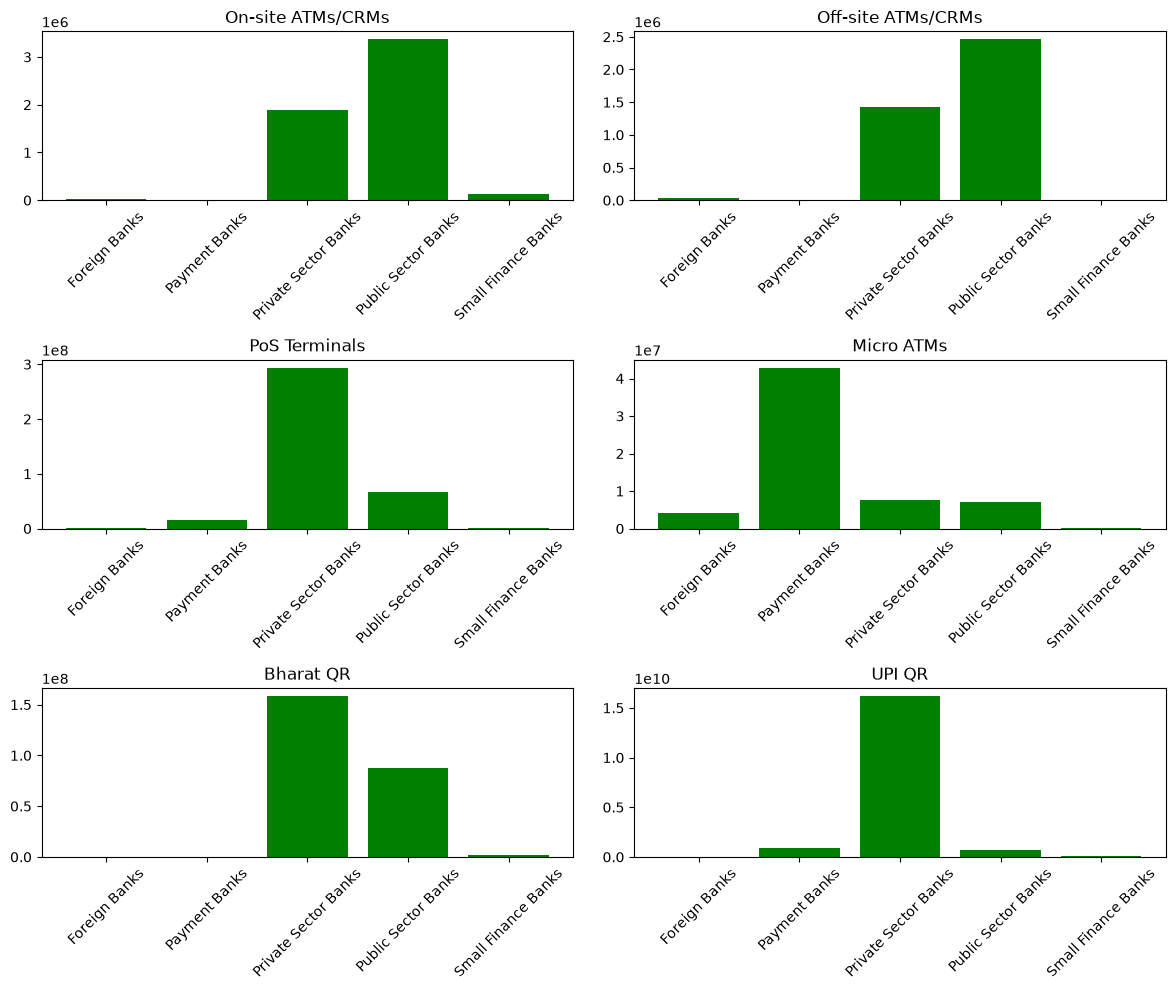

In [15]:
# A subplot visualization is used to display each infrastructure measure separately, making the comparison between bank categories

x = bank_infra.index

plt.figure(figsize=(12, 10))

plt.subplot(3, 2, 1)
plt.bar(x, bank_infra["atms_crms_onsite"], color = "green")
plt.title("On-site ATMs/CRMs")
plt.xticks(rotation=45)

plt.subplot(3, 2, 2)
plt.bar(x, bank_infra["atms_crms_offsite"], color = "green")
plt.title("Off-site ATMs/CRMs")
plt.xticks(rotation=45)

plt.subplot(3, 2, 3)
plt.bar(x, bank_infra["pos"], color = "green")
plt.title("PoS Terminals")
plt.xticks(rotation=45)

plt.subplot(3, 2, 4)
plt.bar(x, bank_infra["micro_atms"], color = "green")
plt.title("Micro ATMs")
plt.xticks(rotation=45)

plt.subplot(3, 2, 5)
plt.bar(x, bank_infra["bharat_qr"], color = "green")
plt.title("Bharat QR")
plt.xticks(rotation=45)

plt.subplot(3, 2, 6)
plt.bar(x, bank_infra["upi_qr"], color = "green")
plt.title("UPI QR")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 5.2 Card Penetration Analysis

In [17]:
# Study the number of outstanding credit cards and debit cards across different bank categories and banks.

Card_Analysis = df.groupby("bank_category")[["credit_cards","debit_cards"]].sum()
Card_Analysis

,credit_cards,debit_cards
bank_category,,
Foreign Banks,226199091,204131204
Payment Banks,0,2670393002
Private Sector Banks,2871267523,9909534342
Public Sector Banks,976327960,27484577420
Small Finance Banks,32626927,1283424038


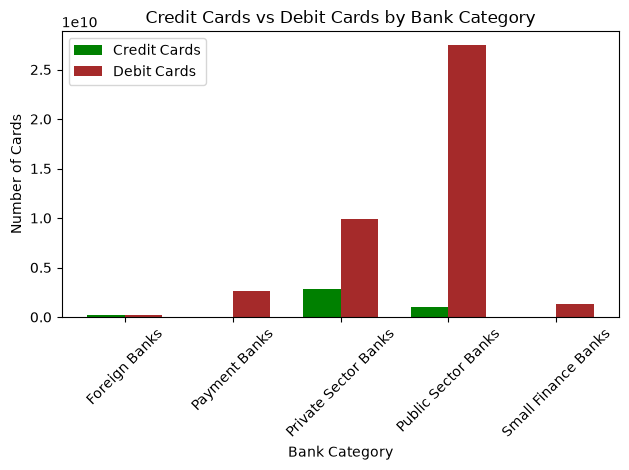

In [19]:
# A grouped bar chart visualization is used to display outstanding credit cards and debit cards to compare card penetration across different 
# bank categories.

x = np.arange(len(Card_Analysis.index))
width = 0.35

plt.bar(x - width/2, Card_Analysis["credit_cards"], width, label="Credit Cards", color="green")
plt.bar(x + width/2, Card_Analysis["debit_cards"], width, label="Debit Cards", color="brown")

plt.xticks(x, Card_Analysis.index, rotation=45)
plt.xlabel("Bank Category")
plt.ylabel("Number of Cards")
plt.title("Credit Cards vs Debit Cards by Bank Category")
plt.legend()

plt.tight_layout()
plt.show()

## 5.3 Analyze Credit card usage

In [10]:
# Compare credit card transactions through: PoS, Online channels, Other channels & ATM cash withdrawals

credit_card_usage = df.groupby("bank_category")[["cc_pay_trns_at_pos_vol","cc_pay_trns_online_vol","cc_pay_trns_other_vol",
                                                 "cc_cash_withdraw_atm_vol"]].sum()
credit_card_usage

,cc_pay_trns_at_pos_vol,cc_pay_trns_online_vol,cc_pay_trns_other_vol,cc_cash_withdraw_atm_vol
bank_category,,,,
Foreign Banks,2.727792e+08,3.691502e+08,0.0,7.905797e+06
Payment Banks,0.000000e+00,0.000000e+00,0.0,0.000000e+00
Private Sector Banks,5.731498e+09,4.912385e+09,1949.0,1.061879e+08
Public Sector Banks,1.385554e+09,1.550328e+09,1741.0,5.030852e+07
Small Finance Banks,3.483280e+07,5.718876e+07,11187465.0,1.157288e+06


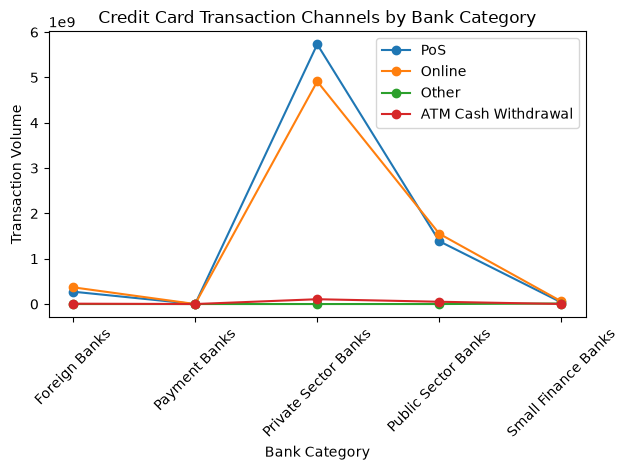

In [69]:
# A line plot is used to compare credit card transaction volumes across PoS, Online, Other channels and ATM cash withdrawals for 
# different bank categories

x = credit_card_usage.index

plt.plot(x, credit_card_usage["cc_pay_trns_at_pos_vol"], marker="o", label="PoS")
plt.plot(x, credit_card_usage["cc_pay_trns_online_vol"], marker="o", label="Online")
plt.plot(x, credit_card_usage["cc_pay_trns_other_vol"], marker="o", label="Other")
plt.plot(x, credit_card_usage["cc_cash_withdraw_atm_vol"], marker="o",
         label="ATM Cash Withdrawal")

plt.xlabel("Bank Category")
plt.ylabel("Transaction Volume")
plt.title("Credit Card Transaction Channels by Bank Category")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

## 5.4 Analyze debit card usage

In [11]:
# Examine debit card transactions through PoS, online, other channels and cash withdrawals

debit_card_usage = df.groupby("bank_category")[["dc_pay_trns_at_pos_vol","dc_pay_trns_online_vol","dc_pay_trns_other_vol",
                                                 "dc_cash_withdraw_atm_vol"]].sum()
debit_card_usage

,dc_pay_trns_at_pos_vol,dc_pay_trns_online_vol,dc_pay_trns_other_vol,dc_cash_withdraw_atm_vol
bank_category,,,,
Foreign Banks,66953776,27280013,5510,4.918755e+08
Payment Banks,21818668,54492655,24687,4.839264e+08
Private Sector Banks,2208649581,1139926763,8597978,3.477558e+10
Public Sector Banks,3503800699,1219901293,816285,7.537692e+10
Small Finance Banks,43248106,17537757,9196,1.658287e+09


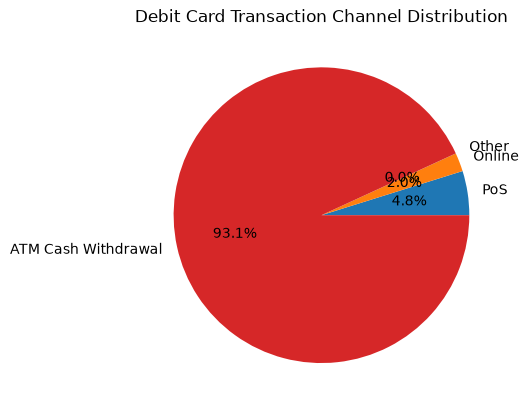

In [71]:
# A pie chart visualization is used to show the proportion of debit card transactions made through PoS, Online, Other channels and ATM cash withdrawals


debit_channels = debit_card_usage.sum()

plt.pie(
    debit_channels,
    labels=["PoS", "Online", "Other", "ATM Cash Withdrawal"],
    autopct="%1.1f%%"
)

plt.title("Debit Card Transaction Channel Distribution")
plt.show()

## 5.5 Compare transaction volume and value

In [12]:
# Identify whether different payment channels are predominantly used for high-volume or high-value transactions.
# Credit Card — Volume vs Value

credit_vol_val = df.groupby("bank_category")[[
    "cc_pay_trns_at_pos_vol",
    "cc_pay_trns_at_pos_val",
    "cc_pay_trns_online_vol",
    "cc_pay_trns_online_val",
    "cc_pay_trns_other_vol",
    "cc_pay_trns_other_val",
    "cc_cash_withdraw_atm_vol",
    "cc_cash_withdraw_atm_val"
]].sum()
credit_vol_val

,cc_pay_trns_at_pos_vol,cc_pay_trns_at_pos_val,cc_pay_trns_online_vol,cc_pay_trns_online_val,cc_pay_trns_other_vol,cc_pay_trns_other_val,cc_cash_withdraw_atm_vol,cc_cash_withdraw_atm_val
bank_category,,,,,,,,
Foreign Banks,2.727792e+08,1.161597e+09,3.691502e+08,2.529909e+09,0.0,0.00,7.905797e+06,1349964.0
Payment Banks,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.00,0.000000e+00,0.0
Private Sector Banks,5.731498e+09,1.827126e+10,4.912385e+09,3.090931e+10,1949.0,120332.78,1.061879e+08,20491377.0
Public Sector Banks,1.385554e+09,4.851172e+09,1.550328e+09,8.162992e+09,1741.0,3620.13,5.030852e+07,10769090.0
Small Finance Banks,3.483280e+07,1.988403e+08,5.718876e+07,2.983038e+08,11187465.0,2145018.30,1.157288e+06,199291.0


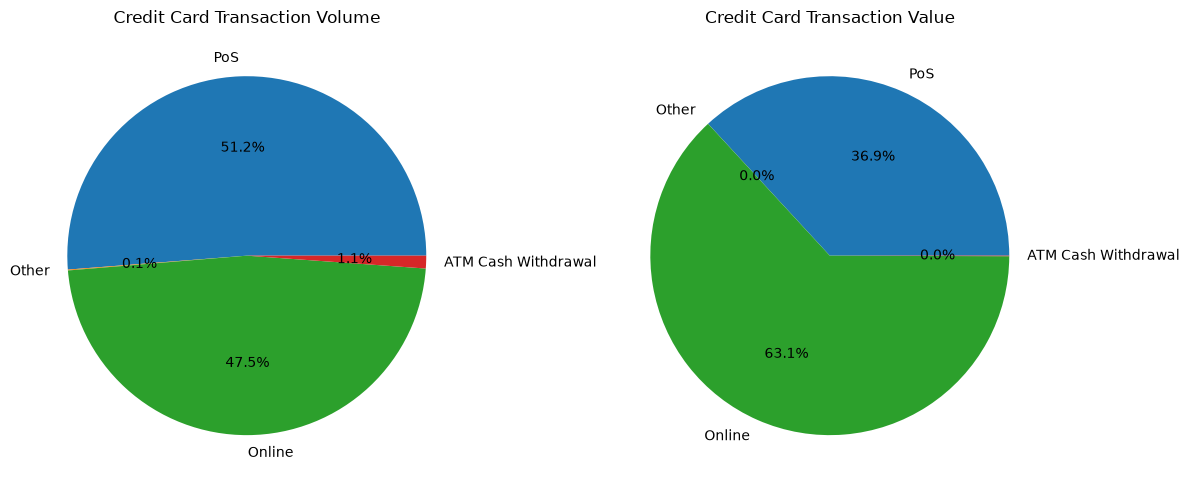

In [76]:
# A Pie Chart is used to examine the relationship between transaction volume and transaction value across different credit card payment channels

volume = [
    credit_vol_val["cc_pay_trns_at_pos_vol"].sum(),
    credit_vol_val["cc_pay_trns_other_vol"].sum(),
    credit_vol_val["cc_pay_trns_online_vol"].sum(),
    credit_vol_val["cc_cash_withdraw_atm_vol"].sum()
]

value = [
    credit_vol_val["cc_pay_trns_at_pos_val"].sum(),
    credit_vol_val["cc_pay_trns_other_val"].sum(),
    credit_vol_val["cc_pay_trns_online_val"].sum(),
    credit_vol_val["cc_cash_withdraw_atm_val"].sum()
]

channels = ["PoS", "Other", "Online", "ATM Cash Withdrawal"]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.pie(volume, labels=channels, autopct="%1.1f%%")
plt.title("Credit Card Transaction Volume")

plt.subplot(1, 2, 2)
plt.pie(value, labels=channels, autopct="%1.1f%%")
plt.title("Credit Card Transaction Value")

plt.tight_layout()
plt.show()

In [18]:
# Debit Card — Volume vs Value

debit_vol_val = df.groupby("bank_category")[[
    "dc_pay_trns_at_pos_vol",
    "dc_pay_trns_at_pos_val",
    "dc_pay_trns_online_vol",
    "dc_pay_trns_online_val",
    "dc_pay_trns_other_vol",
    "dc_pay_trns_other_val",
    "dc_cash_withdraw_atm_vol",
    "dc_cash_withdraw_atm_val",
    "dc_cash_withdraw_pos_vol",
    "dc_cash_withdraw_pos_val"
]].sum()
debit_vol_val

,dc_pay_trns_at_pos_vol,dc_pay_trns_at_pos_val,dc_pay_trns_online_vol,dc_pay_trns_online_val,dc_pay_trns_other_vol,dc_pay_trns_other_val,dc_cash_withdraw_atm_vol,dc_cash_withdraw_atm_val,dc_cash_withdraw_pos_vol,dc_cash_withdraw_pos_val
bank_category,,,,,,,,,,
Foreign Banks,66953776,1.809297e+08,27280013,7.927116e+07,5510,8.640969e+04,4.918755e+08,96485472,131783.03,52890
Payment Banks,21818668,3.123001e+07,54492655,6.612101e+07,24687,1.142172e+04,4.839264e+08,139630174,3403.42,5593
Private Sector Banks,2208649581,5.896621e+09,1139926763,4.133866e+09,8597978,1.030538e+08,3.477558e+10,6026652735,1651688.61,1656454
Public Sector Banks,3503800699,7.695096e+09,1219901293,2.612732e+09,816285,1.010896e+07,7.537692e+10,16129071938,3059152.45,3137529
Small Finance Banks,43248106,8.405432e+07,17537757,5.926588e+07,9196,1.399643e+05,1.658287e+09,388778553,22415.15,17289


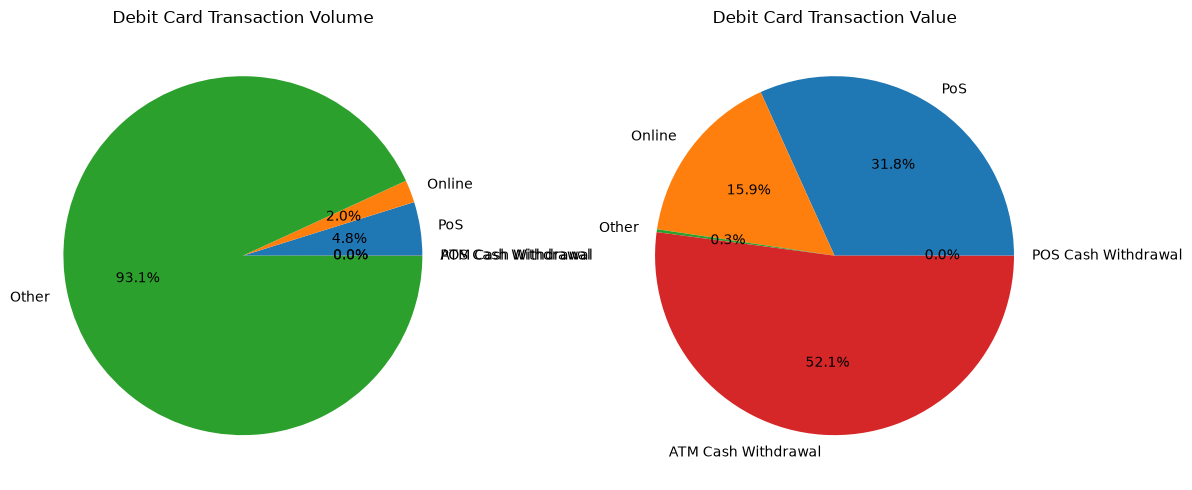

In [79]:
# A pie chart visualization is used to show the proportion of debit card transaction volume and transaction value across different payment channels.

volume = [
    debit_vol_val["dc_pay_trns_at_pos_vol"].sum(),
    debit_vol_val["dc_pay_trns_online_vol"].sum(),
    debit_vol_val["dc_cash_withdraw_atm_vol"].sum(),
    debit_vol_val["dc_pay_trns_other_vol"].sum(),
    debit_vol_val["dc_cash_withdraw_pos_vol"].sum()
]

value = [
    debit_vol_val["dc_pay_trns_at_pos_val"].sum(),
    debit_vol_val["dc_pay_trns_online_val"].sum(),
    debit_vol_val["dc_pay_trns_other_val"].sum(),
    debit_vol_val["dc_cash_withdraw_atm_val"].sum(),
    debit_vol_val["dc_cash_withdraw_pos_val"].sum()
]

channels = [
    "PoS",
    "Online",
    "Other",
    "ATM Cash Withdrawal",
    "POS Cash Withdrawal"
]
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.pie(volume, labels=channels, autopct="%1.1f%%")
plt.title("Debit Card Transaction Volume")

plt.subplot(1, 2, 2)
plt.pie(value, labels=channels, autopct="%1.1f%%")
plt.title("Debit Card Transaction Value")

plt.tight_layout()
plt.show()


## 5.6 Study trends over time

In [19]:
# Analyze how digital payment infrastructure and card transactions have changed from 2022 onwards.

df["date"].min()

'2022-03-01'

In [20]:
df["date"].max()

'2025-09-01'

In [7]:
df["year"] = df["date"].dt.year

### Digital Payment Infrastructure — Year-wise

In [24]:
yearly_infra = df.groupby("year")[[
    "atms_crms_onsite",
    "atms_crms_offsite",
    "pos",
    "micro_atms",
    "bharat_qr",
    "upi_qr"
]].sum()
yearly_infra

,atms_crms_onsite,atms_crms_offsite,pos,micro_atms,bharat_qr,upi_qr
year,,,,,,
2022,1198866.0,972765.0,67981228,11542314,46117348,2055640262
2023,1492782.0,1137153.0,97117091,18392801,67823621,3341800485
2024,1527565.0,1076333.0,109695026,18813601,74934791,6367918083
2025,1185311.0,724597.0,102859046,13232712,59135349,6053357283


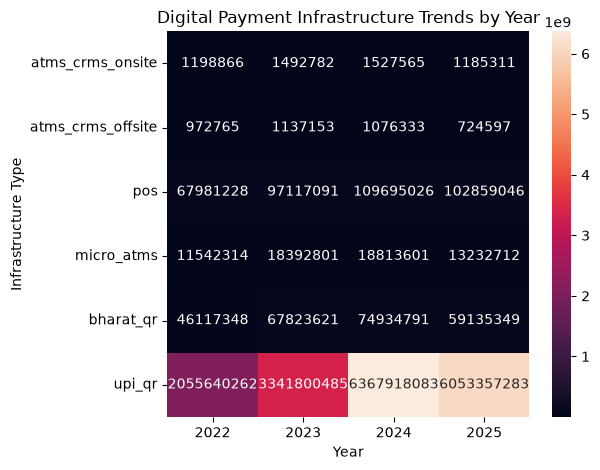

In [83]:
# A heatmap visualization is used to compare digital payment infrastructure across different years,


infra_year = yearly_infra.T

sns.heatmap(
    infra_year,
    annot=True,
    fmt=".0f"
)

plt.title("Digital Payment Infrastructure Trends by Year")
plt.xlabel("Year")
plt.ylabel("Infrastructure Type")

plt.tight_layout()
plt.show()

### Card Transactions — Year-wise

In [25]:
# Credit cards

yearly_credit = df.groupby("year")[[
    "cc_pay_trns_at_pos_vol",
    "cc_pay_trns_online_vol",
    "cc_pay_trns_other_vol",
    "cc_cash_withdraw_atm_vol"
]].sum()

yearly_credit

,cc_pay_trns_at_pos_vol,cc_pay_trns_online_vol,cc_pay_trns_other_vol,cc_cash_withdraw_atm_vol
year,,,,
2022,1.266312e+09,1.116849e+09,13325.0,34952725.23
2023,1.753962e+09,1.578004e+09,16667.0,45483640.07
2024,2.323518e+09,2.147891e+09,618813.0,51362460.44
2025,2.080872e+09,2.046307e+09,10542350.0,33760684.79


In [26]:
# Debit cards

yearly_debit = df.groupby("year")[[
    "dc_pay_trns_at_pos_vol",
    "dc_pay_trns_online_vol",
    "dc_pay_trns_other_vol",
    "dc_cash_withdraw_atm_vol"
]].sum()

yearly_debit

,dc_pay_trns_at_pos_vol,dc_pay_trns_online_vol,dc_pay_trns_other_vol,dc_cash_withdraw_atm_vol
year,,,,
2022,2000651508,1023701240,5324004,2.754999e+10
2023,1798883827,724738755,1940853,3.267331e+10
2024,1283608095,452987512,1412109,3.091243e+10
2025,761327400,257710974,776690,2.165086e+10


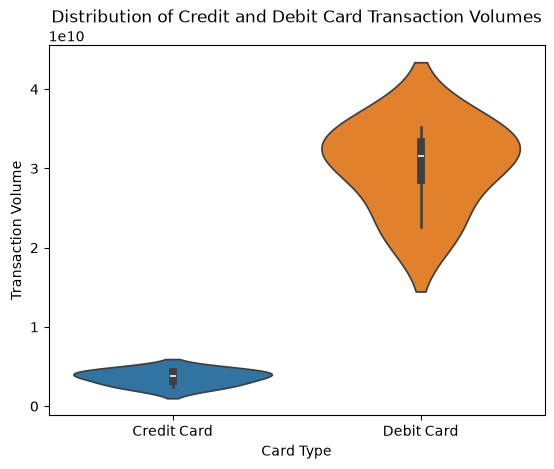

In [80]:
# A violin plot is used to compare the distribution of yearly credit card and debit card transaction volumes from 2022 onwards


credit_total = yearly_credit.sum(axis=1)
debit_total = yearly_debit.sum(axis=1)

comparison = pd.DataFrame({
    "Credit Card": credit_total,
    "Debit Card": debit_total
})

sns.violinplot(data=comparison)

plt.title("Distribution of Credit and Debit Card Transaction Volumes")
plt.xlabel("Card Type")
plt.ylabel("Transaction Volume")

plt.show()

## 5.7 Compare banks and digital-payment infrastructure

In [85]:
# Identify banks/bank categories with higher digital-payment infrastructure.

ind_bank = df.groupby("bank_name")[[
    "atms_crms_onsite",
    "atms_crms_offsite",
    "pos",
    "micro_atms",
    "bharat_qr",
    "upi_qr"
]].sum()

ind_bank.sort_values("upi_qr", ascending=False)

,atms_crms_onsite,atms_crms_offsite,pos,micro_atms,bharat_qr,upi_qr
bank_name,,,,,,
Yes Bank,48338.0,7297.0,3285244,3788413,12279788,12395779803
Axis Bank,262368.0,395349.0,72288583,26616,27035907,3165091153
Paytm Payments Bank,24.0,1075.0,14840016,0,0,731277457
Federal Bank,70572.0,14289.0,834241,12753,1334629,203781392
IndusInd Bank,76796.0,49343.0,10057541,5213,2036638,195001747
...,...,...,...,...,...,...
SLICE SMALL FINANCE BANK LTD,70.0,4.0,0,0,0,0
Suryoday Small Finance Bank,516.0,3.0,0,2880,0,0
Standard Chartered Bank,4330.0,2538.0,0,0,0,0


## 8. Identify important banking patterns

In [91]:
# Determine the major channels driving card-based transactions and identify changes in customer payment behaviour

# Identify the Major Card Transaction Channels

# Credit Cards

credit_channels = df[[
    "cc_pay_trns_at_pos_vol",
    "cc_pay_trns_other_vol",
    "cc_pay_trns_online_vol",
    "cc_cash_withdraw_atm_vol"
]].sum()

credit_channels.sort_values(ascending=False)

cc_pay_trns_at_pos_vol      7.424663e+09
cc_pay_trns_online_vol      6.889051e+09
cc_cash_withdraw_atm_vol    1.655595e+08
cc_pay_trns_other_vol       1.119116e+07
dtype: float64

In [36]:
# Debit Cards

debit_channels = df[[
    "dc_pay_trns_at_pos_vol",
    "dc_pay_trns_online_vol",
    "dc_pay_trns_other_vol",
    "dc_cash_withdraw_atm_vol"
]].sum()

debit_channels.sort_values(ascending=False)

dc_cash_withdraw_atm_vol    1.127866e+11
dc_pay_trns_at_pos_vol      5.844471e+09
dc_pay_trns_online_vol      2.459138e+09
dc_pay_trns_other_vol       9.453656e+06
dtype: float64

In [37]:
# Identify Changes in Payment Behaviour Over Time

yearly_card = df.groupby("year")[[
    "cc_pay_trns_at_pos_vol",
    "cc_pay_trns_online_vol",
    "dc_pay_trns_at_pos_vol",
    "dc_pay_trns_online_vol"
]].sum()

yearly_card

,cc_pay_trns_at_pos_vol,cc_pay_trns_online_vol,dc_pay_trns_at_pos_vol,dc_pay_trns_online_vol
year,,,,
2022,1.266312e+09,1.116849e+09,2000651508,1023701240
2023,1.753962e+09,1.578004e+09,1798883827,724738755
2024,2.323518e+09,2.147891e+09,1283608095,452987512
2025,2.080872e+09,2.046307e+09,761327400,257710974


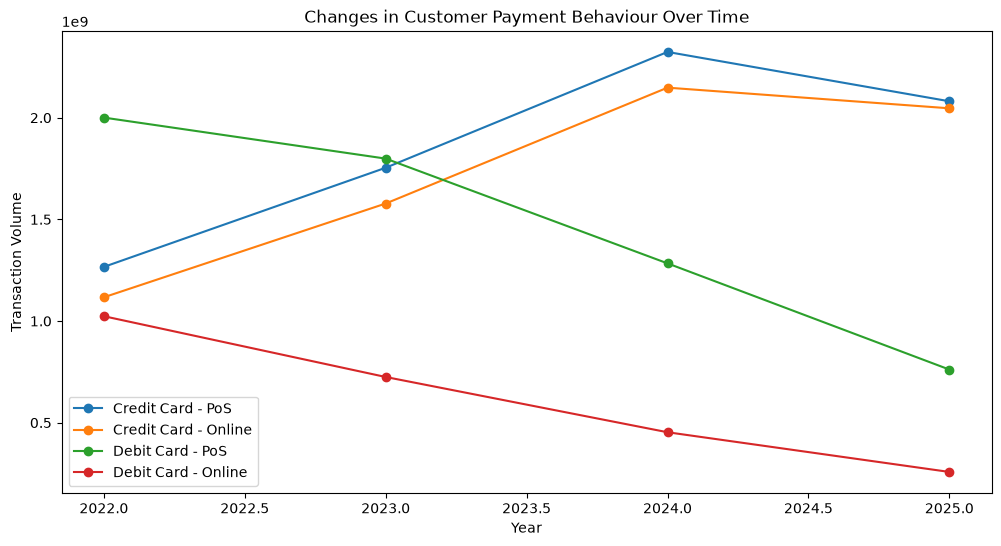

In [94]:
# A line plot visualization is used to examine changes in customer payment behaviour over time by comparing PoS and Online transaction volumes 
# for credit and debit cards.

x = yearly_card.index

plt.figure(figsize=(12, 6))

plt.plot(x, yearly_card["cc_pay_trns_at_pos_vol"],
         marker="o", label="Credit Card - PoS")

plt.plot(x, yearly_card["cc_pay_trns_online_vol"],
         marker="o", label="Credit Card - Online")

plt.plot(x, yearly_card["dc_pay_trns_at_pos_vol"],
         marker="o", label="Debit Card - PoS")

plt.plot(x, yearly_card["dc_pay_trns_online_vol"],
         marker="o", label="Debit Card - Online")

plt.xlabel("Year")
plt.ylabel("Transaction Volume")
plt.title("Changes in Customer Payment Behaviour Over Time")
plt.legend()

plt.show()

In [8]:
# Compare Digital Infrastructure Changes

yearly_digital = df.groupby("year")[[
    "pos",
    "micro_atms",
    "bharat_qr",
    "upi_qr"
]].sum()

yearly_digital

,pos,micro_atms,bharat_qr,upi_qr
year,,,,
2022,67981228,11542314,46117348,2055640262
2023,97117091,18392801,67823621,3341800485
2024,109695026,18813601,74934791,6367918083
2025,102859046,13232712,59135349,6053357283


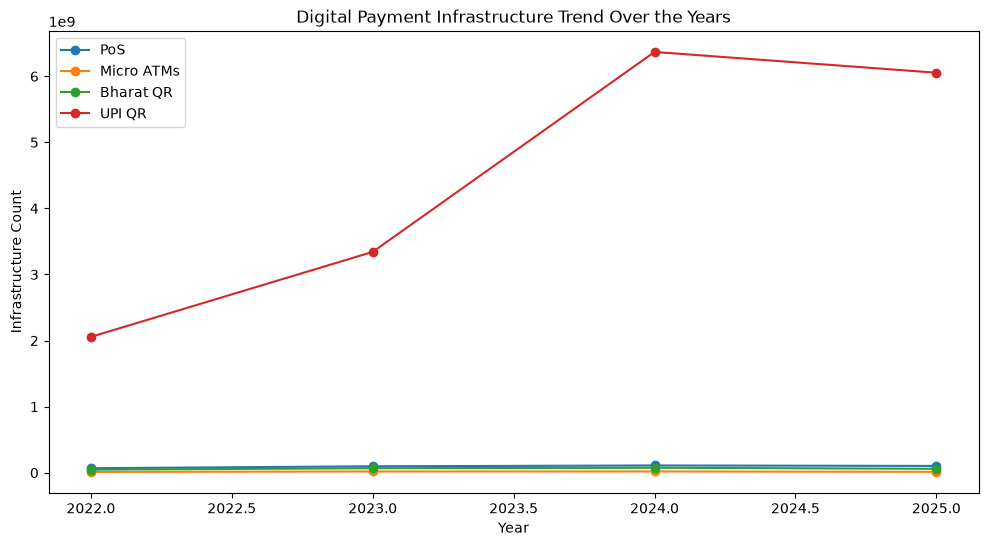

In [9]:
# A line plot visualization is used to show year-wise changes in digital payment infrastructure, making it easier to identify 
# increasing or decreasing trends in PoS, Micro ATMs, Bharat QR and UPI QR from 2022 onwards.

plt.figure(figsize=(12, 6))

plt.plot(yearly_digital.index, yearly_digital["pos"],
         marker="o", label="PoS")

plt.plot(yearly_digital.index, yearly_digital["micro_atms"],
         marker="o", label="Micro ATMs")

plt.plot(yearly_digital.index, yearly_digital["bharat_qr"],
         marker="o", label="Bharat QR")

plt.plot(yearly_digital.index, yearly_digital["upi_qr"],
         marker="o", label="UPI QR")

plt.xlabel("Year")
plt.ylabel("Infrastructure Count")
plt.title("Digital Payment Infrastructure Trend Over the Years")
plt.legend()

plt.show()



# Step 6 : Insights and Key Findings

The analysis indicates a clear difference in payment behaviour between credit and debit cards. Credit-card transactions are primarily driven by PoS and Online channels, whereas debit-card transaction volume is overwhelmingly dominated by ATM cash withdrawals. At the same time, digital-payment infrastructure, particularly UPI QR and PoS, expanded considerably during the study period, indicating increasing availability of digital payment facilities.

## 1. Private Sector Banks have strong digital infrastructure

Private Sector Banks have a strong presence in digital-payment infrastructure, particularly in PoS, Micro ATMs, Bharat QR and UPI QR, indicating greater deployment of digital payment channels.

## 2. Debit cards substantially outnumber credit cards

Debit cards have significantly higher outstanding numbers than credit cards, indicating their wider penetration among customers, particularly in Public and Private Sector Banks.

## 3. Private Sector Banks dominate credit-card transactions

Private Sector Banks are the major contributors to credit-card transaction activity, with PoS and Online channels accounting for most of their transaction volume.

## 4. Credit-card usage is concentrated in PoS and Online channels

Credit-card transactions are predominantly driven by PoS and Online payment channels, whereas ATM cash withdrawals and Other channels have relatively smaller contributions.

## 5. Debit-card transactions are heavily dominated by ATM cash withdrawals

Debit-card transaction volume is overwhelmingly dominated by ATM cash withdrawals, accounting for approximately 93.1% of the total, while PoS and Online transactions contribute much smaller shares.

## 6. Credit-card transaction value does not follow exactly the same pattern as transaction volume

The distribution of credit-card transaction value differs from transaction volume, indicating that payment channels with fewer transactions can still contribute significantly to overall transaction value.

## 7. Debit-card transaction volume and value show a major difference

Debit-card transaction volume is highly concentrated in ATM cash withdrawals, whereas transaction value is distributed more broadly across payment and withdrawal channels, indicating that transaction frequency and transaction size do not necessarily follow the same pattern.

## 8. Credit-card transactions increased strongly from 2022 to 2024

Credit-card transaction activity increased substantially between 2022 and 2024 across both PoS and Online channels, followed by a moderate decline in 2025.

## 9. Debit-card PoS and Online transactions declined over the period

Debit-card PoS and Online transaction volumes show a declining trend from 2022 onwards, indicating a reduction in these types of debit-card transactions during the study period.

## 10. UPI QR infrastructure shows exceptional growth

UPI QR infrastructure shows exceptionally high growth and scale compared with other digital-payment infrastructure measures, highlighting the rapid expansion of QR-based digital payment infrastructure during the study period.

## 11. PoS infrastructure also expanded considerably

PoS infrastructure expanded substantially from 2022 to 2024, indicating increased deployment of card-acceptance infrastructure, although the level moderated in 2025.

## 12. Micro ATMs and Bharat QR also expanded before declining in 2025

Micro ATM and Bharat QR infrastructure increased between 2022 and 2024 but showed a decline in 2025, suggesting that infrastructure growth was not uniform across all digital-payment channels.

# Step 7 : Conclusion

Overall, the study highlights the growth of digital-payment infrastructure in India and significant differences in customer payment behaviour across credit and debit cards. Private Sector Banks show strong digital infrastructure and credit-card activity, while debit-card transactions remain heavily dominated by ATM cash withdrawals. UPI QR and PoS infrastructure show strong expansion from 2022 onwards, indicating the increasing importance of digital payment channels.